In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats
import warnings

In [3]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_serv_clean.csv")
df.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,69.0,79,82,435.609756,325.202683,257.561707,262.395732
1,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,30.0,30,35,448.285714,439.852857,351.134286,315.416286
2,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,84.0,99,107,108.457944,66.980000,51.914953,46.384393
3,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3913,"Hand finger orthosis, without joints, may incl...",N,16.0,16,16,348.000000,247.410000,197.133125,191.759375
4,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3923,"Hand finger orthosis, without joints, may incl...",N,54.0,59,66,113.030303,88.250000,66.411515,65.491667


In [8]:
# Data types
df.info()

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_%": missing_percent
})

missing_df.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454474 entries, 0 to 1454473
Data columns (total 37 columns):
year                         1454474 non-null int64
suplr_npi                    1454474 non-null int64
suplr_prvdr_last_name_org    1454474 non-null object
suplr_prvdr_first_name       3974 non-null object
suplr_prvdr_mi               2984 non-null object
suplr_prvdr_crdntls          3145 non-null object
suplr_prvdr_ent_cd           1454474 non-null object
suplr_prvdr_st1              1454474 non-null object
suplr_prvdr_st2              217163 non-null object
suplr_prvdr_city             1454474 non-null object
suplr_prvdr_state_abrvtn     1454474 non-null object
suplr_prvdr_state_fips       1454474 non-null int64
suplr_prvdr_zip5             1454474 non-null int64
suplr_prvdr_ruca_cat         1454474 non-null object
suplr_prvdr_ruca             1454474 non-null float64
suplr_prvdr_ruca_desc        1454474 non-null object
suplr_prvdr_cntry            1454474 non-null object

,Missing_Count,Missing_%
suplr_prvdr_mi,1451490,99.794840
suplr_prvdr_crdntls,1451329,99.783771
suplr_prvdr_first_name,1450500,99.726774
suplr_prvdr_st2,1237311,85.069310
suplr_prvdr_state_abrvtn,0,0.000000
suplr_prvdr_ruca_desc,0,0.000000
suplr_prvdr_ruca,0,0.000000
suplr_prvdr_ruca_cat,0,0.000000
suplr_prvdr_zip5,0,0.000000
suplr_prvdr_state_fips,0,0.000000


In [9]:
numeric_cols = [
    "tot_suplr_benes",
    "tot_suplr_clms",
    "tot_suplr_srvcs",
    "avg_suplr_sbmtd_chrg",
    "avg_suplr_mdcr_alowd_amt",
    "avg_suplr_mdcr_pymt_amt",
    "avg_suplr_mdcr_stdzd_amt"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tot_suplr_benes,1454474.0,60.153125,480.359113,5.000000,5.000000,14.000000,35.000000,1.127970e+05
tot_suplr_clms,1454474.0,164.779877,1892.079070,11.000000,16.000000,29.000000,79.000000,8.590970e+05
tot_suplr_srvcs,1454474.0,4576.480000,495201.470938,11.000000,27.000000,96.000000,696.000000,2.967321e+08
avg_suplr_sbmtd_chrg,1454474.0,205.687791,902.896712,0.000335,13.211076,36.597250,115.000000,7.761210e+04
avg_suplr_mdcr_alowd_amt,1454474.0,101.062554,419.897111,0.000335,2.799809,16.000000,56.610000,2.773326e+04
avg_suplr_mdcr_pymt_amt,1454474.0,77.982244,328.399810,0.000000,2.087560,12.616471,41.961404,2.174288e+04
avg_suplr_mdcr_stdzd_amt,1454474.0,77.678227,319.337308,0.000000,2.183343,12.540000,43.710000,2.149642e+04


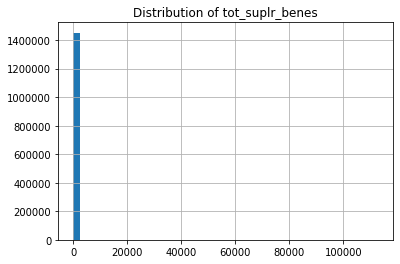

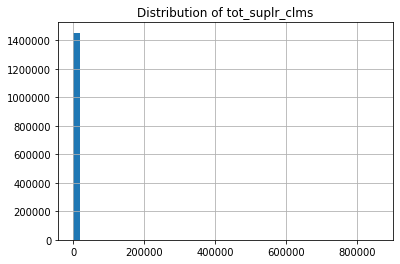

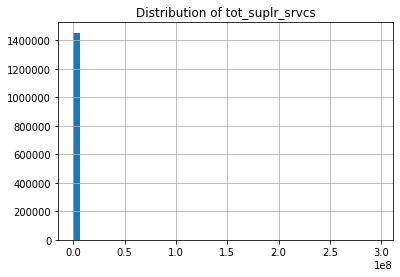

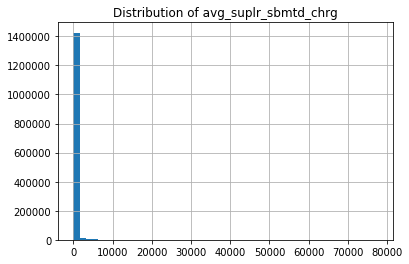

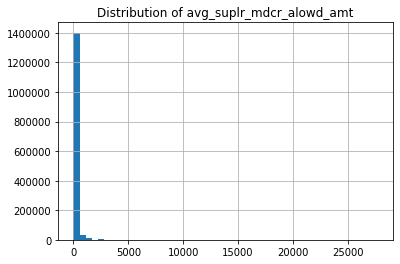

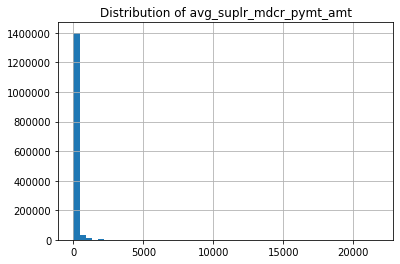

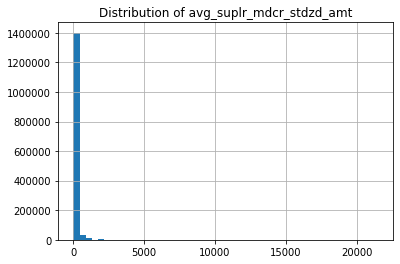

In [10]:
for col in numeric_cols:
    plt.figure()
    df[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [11]:
df["log_payment"] = np.log1p(df["avg_suplr_mdcr_pymt_amt"])
df["log_allowed"] = np.log1p(df["avg_suplr_mdcr_alowd_amt"])
df["log_submitted"] = np.log1p(df["avg_suplr_sbmtd_chrg"])

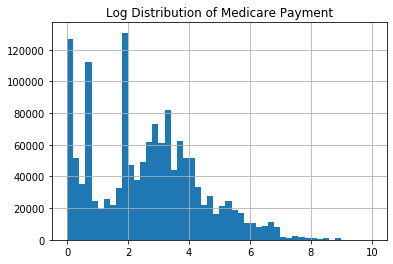

In [12]:
plt.figure()
df["log_payment"].hist(bins=50)
plt.title("Log Distribution of Medicare Payment")
plt.show()

In [13]:
# Markup ratio
df["markup_ratio"] = df["avg_suplr_sbmtd_chrg"] / df["avg_suplr_mdcr_alowd_amt"]

# Payment efficiency
df["payment_efficiency"] = df["avg_suplr_mdcr_pymt_amt"] / df["avg_suplr_sbmtd_chrg"]

# Claim intensity
df["services_per_claim"] = df["tot_suplr_srvcs"] / df["tot_suplr_clms"]

In [14]:
df[["markup_ratio", "payment_efficiency", "services_per_claim"]].describe()

,markup_ratio,payment_efficiency,services_per_claim
count,1.454474e+06,1.454474e+06,1.454474e+06
mean,5.065572e+00,3.667241e-01,3.886597e+01
std,2.694614e+01,2.557175e-01,2.371180e+02
min,2.545599e-01,0.000000e+00,1.000000e+00
25%,1.257011e+00,1.063536e-01,1.000000e+00
50%,2.228626e+00,3.348731e-01,1.188679e+00
75%,6.833058e+00,6.017448e-01,5.918705e+00
max,1.257520e+04,3.079854e+00,1.240909e+04


In [15]:
df["z_payment"] = (
    df["avg_suplr_mdcr_pymt_amt"] - df["avg_suplr_mdcr_pymt_amt"].mean()
) / df["avg_suplr_mdcr_pymt_amt"].std()

outliers = df[df["z_payment"] > 3]

print("Extreme high payment rows:", outliers.shape)
outliers.sort_values("z_payment", ascending=False).head()

Extreme high payment rows: (11854, 41)


,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,markup_ratio,payment_efficiency,log_payment,sprsn_flag,log_allowed,log_submitted,services_per_claim,z_payment
1355392,2023,1780824094,"Orthotic & Prosthetic Centers, Inc.",NaN,NaN,NaN,O,13710 Metropolis Ave Ste 107,NaN,Fort Myers,...,21742.880000,21496.42,1.400000,0.560000,9.987088,0,10.230424,10.566886,1.076923,65.971103
1174426,2023,1407811375,"Scheck & Siress Prosthetics, Inc",NaN,NaN,NaN,O,1701 E Woodfield Rd Ste 555,NaN,Schaumburg,...,21625.680000,21496.42,1.416267,0.553568,9.981683,0,10.225019,10.573033,1.000000,65.614221
1047406,2023,1124099031,"Progressive O & P, Inc",NaN,NaN,NaN,O,1111 Willis Avenue,NaN,Albertson,...,21265.221818,21496.42,1.296194,0.604848,9.964875,0,10.208211,10.467635,1.000000,64.516601
1391850,2023,1861690026,A Step Ahead Prosthetics & Orthotics,NaN,NaN,NaN,O,132 Newbridge Rd,NaN,Hicksville,...,21202.970000,21496.42,1.008640,0.777285,9.961944,0,10.205280,10.213882,1.000000,64.327040
1224293,2023,1508954157,"Eastern Cranial Affiliates, Llc",NaN,NaN,NaN,O,10523 Main St,NaN,Fairfax,...,21066.179091,21496.42,1.221469,0.641850,9.955472,0,10.198808,10.398855,1.000000,63.910502


In [16]:
supplier_agg = (
    df.groupby("suplr_npi")
    .agg(
        total_services=("tot_suplr_srvcs", "sum"),
        total_claims=("tot_suplr_clms", "sum"),
        median_payment=("avg_suplr_mdcr_pymt_amt", "median"),
        mean_markup=("markup_ratio", "mean"),
        mean_efficiency=("payment_efficiency", "mean")
    )
    .reset_index()
)

supplier_agg.head()

,suplr_npi,total_services,total_claims,median_payment,mean_markup,mean_efficiency
0,1003000399,754,707,157.570789,1.288877,0.611667
1,1003002254,17749,680,3.257557,7.455893,0.293605
2,1003004904,2463,218,5.841414,8.369609,0.280578
3,1003004938,31291,547,1.064807,8.735717,0.211330
4,1003007386,20954,607,5.368885,5.791223,0.342629


In [17]:
supplier_agg["z_supplier_payment"] = (
    supplier_agg["median_payment"] - supplier_agg["median_payment"].mean()
) / supplier_agg["median_payment"].std()

high_risk_suppliers = supplier_agg[supplier_agg["z_supplier_payment"] > 3]

high_risk_suppliers.sort_values("z_supplier_payment", ascending=False).head()

,suplr_npi,total_services,total_claims,median_payment,mean_markup,mean_efficiency,z_supplier_payment
17634,1255617569,11771,11771,11109.138809,1.474089,0.538258,66.863586
16325,1235516055,288,288,4176.234839,1.657621,0.532947,24.939203
34612,1508319401,52,52,3955.161818,1.693572,0.572978,23.602339
2091,1023642428,39,39,3903.710000,1.058799,0.743564,23.291202
57842,1831733955,30,30,3788.945625,1.492612,0.527082,22.597203


In [18]:
hcpcs_summary = (
    df.groupby("hcpcs_cd")
    .agg(
        median_payment=("avg_suplr_mdcr_pymt_amt", "median"),
        mean_markup=("markup_ratio", "mean"),
        total_services=("tot_suplr_srvcs", "sum")
    )
    .reset_index()
)

hcpcs_summary.sort_values("median_payment", ascending=False).head(10)

,hcpcs_cd,median_payment,mean_markup,total_services
1164,L5856,20102.524615,1.223398,202
1175,L5973,14452.699091,1.248474,36
481,E0766,11109.138809,1.474089,11771
529,E1007,7124.845000,2.003840,42938
530,E1008,7085.390714,1.165566,14
1182,L5987,5917.816250,1.256863,341
528,E1006,5322.483333,1.054985,12
459,E0652,4969.044105,1.308827,9190
844,K0861,4708.786846,2.280628,31883
843,K0856,4604.505192,2.580849,2405


In [22]:
if "ruca_cat_desc" in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=df,
        x="ruca_cat_desc",
        y="log_payment"
    )
    plt.xticks(rotation=45)
    plt.title("Log Payment by RUCA Category")
    plt.show()

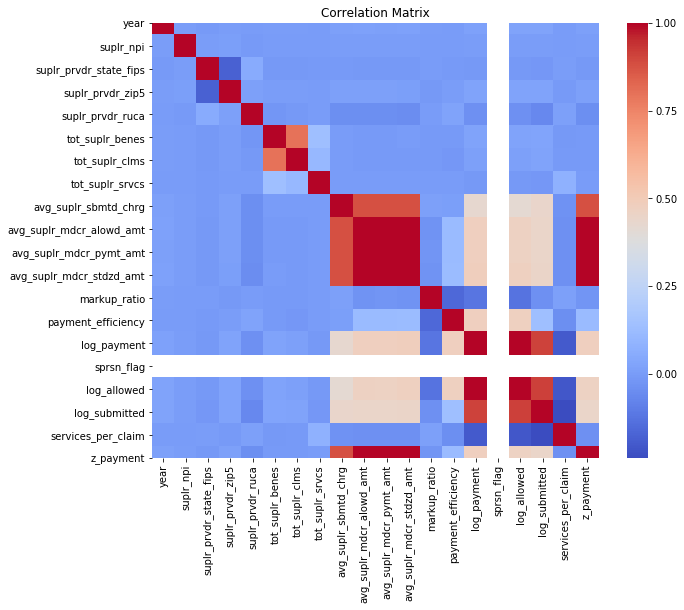

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

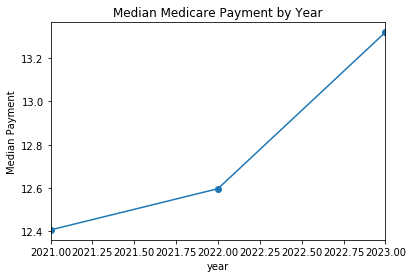

In [24]:
yearly_trend = (
    df.groupby("year")["avg_suplr_mdcr_pymt_amt"]
    .median()
)

yearly_trend.plot(marker="o")
plt.title("Median Medicare Payment by Year")
plt.ylabel("Median Payment")
plt.show()

In [25]:
# Total payment per supplier
supplier_payment = (
    df.groupby("suplr_npi")["avg_suplr_mdcr_pymt_amt"]
    .sum()
    .sort_values(ascending=False)
)

# Top 5% suppliers
top_5_cutoff = int(len(supplier_payment) * 0.05)
top_5_total = supplier_payment.iloc[:top_5_cutoff].sum()
overall_total = supplier_payment.sum()

print("Top 5% control:",
      round((top_5_total / overall_total) * 100, 2), "% of total payments")

Top 5% control: 64.19 % of total payments


In [26]:
def gini(array):
    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    gini_index = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_index

gini_value = gini(supplier_payment.values)
print("Gini Coefficient:", round(gini_value, 3))

Gini Coefficient: 0.859


In [27]:
# Flag unusually high markup
df["high_markup_flag"] = (df["markup_ratio"] > df["markup_ratio"].quantile(0.95)).astype(int)

df["high_markup_flag"].value_counts(normalize=True) * 100

0    94.999979
1     5.000021
Name: high_markup_flag, dtype: float64

In [28]:
high_markup_hcpcs = (
    df[df["high_markup_flag"] == 1]
    .groupby("hcpcs_cd")["markup_ratio"]
    .median()
    .sort_values(ascending=False)
)

high_markup_hcpcs.head(10)

hcpcs_cd
J7612    780.060424
J8597    335.114509
J9039    322.138873
A4624    227.920228
A6445    153.846154
A7004    149.303216
J7631    146.486952
Q0162    142.955509
A6010    131.099782
E0167    123.897855
Name: markup_ratio, dtype: float64

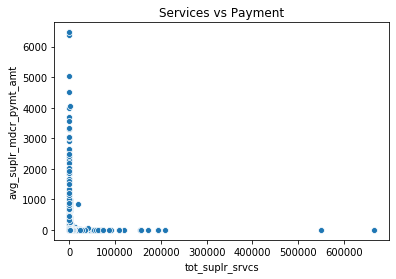

In [29]:
plt.figure()
sns.scatterplot(
    x="tot_suplr_srvcs",
    y="avg_suplr_mdcr_pymt_amt",
    data=df.sample(5000)  # sample to reduce overplotting
)
plt.title("Services vs Payment")
plt.show()

In [30]:
df[["tot_suplr_srvcs", "avg_suplr_mdcr_pymt_amt"]].corr()

,tot_suplr_srvcs,avg_suplr_mdcr_pymt_amt
tot_suplr_srvcs,1.000000,-0.002077
avg_suplr_mdcr_pymt_amt,-0.002077,1.000000


In [31]:
median_services = df["tot_suplr_srvcs"].median()

high_volume = df[df["tot_suplr_srvcs"] > median_services]["avg_suplr_mdcr_pymt_amt"]
low_volume = df[df["tot_suplr_srvcs"] <= median_services]["avg_suplr_mdcr_pymt_amt"]

# Mann-Whitney test (non-parametric)
stat, p = stats.mannwhitneyu(high_volume, low_volume)

print("Mann-Whitney p-value:", p)

Mann-Whitney p-value: 0.0


In [32]:
yearly = (
    df.groupby("year")["avg_suplr_mdcr_pymt_amt"]
    .median()
)

growth_rate = yearly.pct_change() * 100
growth_rate

year
2021         NaN
2022    1.535746
2023    5.739873
Name: avg_suplr_mdcr_pymt_amt, dtype: float64

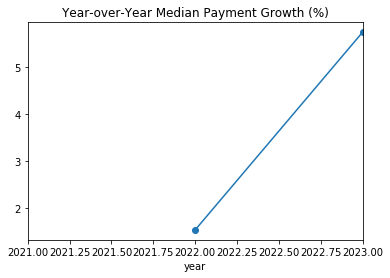

In [33]:
growth_rate.plot(marker="o")
plt.title("Year-over-Year Median Payment Growth (%)")
plt.show()

In [34]:
supplier_diversity = (
    df.groupby("suplr_npi")["hcpcs_cd"]
    .nunique()
    .reset_index(name="unique_hcpcs_count")
)

supplier_diversity.describe()

,suplr_npi,unique_hcpcs_count
count,6.882800e+04,68828.000000
mean,1.499904e+09,9.404588
std,2.878620e+08,13.665945
min,1.003000e+09,1.000000
25%,1.255344e+09,3.000000
50%,1.497938e+09,6.000000
75%,1.740726e+09,10.000000
max,1.992999e+09,300.000000


In [35]:
supplier_diversity.sort_values("unique_hcpcs_count", ascending=False).head()

,suplr_npi,unique_hcpcs_count
63341,1922006741,300
63335,1922001189,294
14067,1205837879,273
404,1003834946,203
49195,1710259551,201


In [36]:
df["efficiency_quartile"] = pd.qcut(
    df["payment_efficiency"],
    4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

df.groupby("efficiency_quartile")["avg_suplr_mdcr_pymt_amt"].median()

efficiency_quartile
Low          0.970923
Mid-Low     14.580096
Mid-High    32.403662
High        23.518182
Name: avg_suplr_mdcr_pymt_amt, dtype: float64

In [37]:
df["risk_score"] = (
    df["z_payment"].clip(lower=0) +
    df["markup_ratio"].rank(pct=True) +
    df["services_per_claim"].rank(pct=True)
)

df["risk_score"] = df["risk_score"] / df["risk_score"].max()

df[["suplr_npi", "hcpcs_cd", "risk_score"]].sort_values("risk_score", ascending=False).head(15)

,suplr_npi,hcpcs_cd,risk_score
1355392,1780824094,L5856,1.000000
1174426,1407811375,L5856,0.990921
1047406,1124099031,L5856,0.973781
1391850,1861690026,L5856,0.969149
1224293,1508954157,L5856,0.964260
748337,1497930887,L5856,0.924942
817081,1649274556,L5856,0.922298
567541,1124075833,L5856,0.919013
824256,1659513554,L5856,0.900344
567747,1124099031,L5856,0.897071


In [38]:
hcpcs_volume = (
    df.groupby("hcpcs_cd")["tot_suplr_srvcs"]
    .sum()
    .sort_values(ascending=False)
)

cumulative = hcpcs_volume.cumsum() / hcpcs_volume.sum()

pd.DataFrame({
    "Volume": hcpcs_volume,
    "Cumulative_%": cumulative
}).head(15)

,Volume,Cumulative_%
hcpcs_cd,,
J7677,2267874837,0.340707
A4353,441402975,0.407020
J7613,394695512,0.466316
B4152,341472223,0.517616
J7507,243559018,0.554207
A4351,226591934,0.588248
J7503,208119093,0.619514
J7620,194775504,0.648776
A4352,184850703,0.676546
